# MR4010 Navegación Autónoma

## Redes Neuronales con Keras

# Clasificación Binaria usando Keras utilziando Breast Cancer dataset

En este notebook se implementa una red neuronal artificial (ANN)
utilizando Keras para resolver un problema de clasificación binaria.

En este notebook se construye una red neuronal con Keras para resolver un problema de clasificación binaria usando el dataset `breast_cancer` de Scikit-Learn.

El objetivo es clasificar tumores como malignos o benignos usando inicialmente dos variables del dataset:

- `mean radius`
- `mean texture`

Posteriormente se entrena una red neuronal simple con una neurona de salida y función de activación sigmoide.

Objetivos:
- Crear un perceptrón simple
- Evaluar desempeño
- Visualizar exactitud y pérdida
- Visualizar la frontera de decisión
- Mejorar el modelo agregando capas ocultas

Lee el capítulo 4 del libro de texto:

Venturi, L. y Korda, K. (2020). Hands-On Vision and Behavior For Self-Driving Cars. Packt Publishing. Disponible en: https://learning.oreilly.com/library/view/hands-on-vision-and/9781800203587/B16322_FM_Final_NM_ePUB.xhtmlLinks to an external site.


Lee el capítulo 2 del libro de texto:

Ranjan, S. y Senthamilarasu S.(2020). Applied Deep Learning and Computer Vision
for Self-Driving Cars. Packt Publishing Ltd.
Links to an external site.https://learning.oreilly.com/library/view/applied-deep-learning/9781838646301/?sso_link=yes&sso_link_from=ITESLinks to an external site.



## Paso 1 - Instalacion de pytorch paar correr en GPU, para esto correr en terminal
Paso a paso

python -m pip install --upgrade pip setuptools wheel

python -m pip install --force-reinstall --no-cache-dir typing-extensions==4.12.2

python -m pip install --no-cache-dir `
  torch==2.7.1+cu128 `
  torchvision==0.22.1+cu128 `
  torchaudio==2.7.1+cu128 `
  --index-url https://download.pytorch.org/whl/cu128

![image.png](attachment:image.png)

In [1]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

Torch: 2.7.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Capability: (12, 0)


# Paso 2 — Cargar bibliotecas

Explicación rápida:

numpy: nos ayuda con matrices, vectores y operaciones matemáticas.

matplotlib: nos ayuda a graficar los datos y la frontera de decisión.

%matplotlib inline: permite que las gráficas aparezcan dentro del notebook.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from matplotlib.colors import ListedColormap

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

print(r'Tensor flow: ',tf.__version__)

Tensor flow:  2.21.0


## Paso 3 - Cargar dataset

### Se carga como DataFrame un dataset de prueba

### Dataset `breast_cancer`

Se carga el dataset `breast_cancer` desde Scikit-Learn.

Este dataset contiene 569 muestras y 30 variables numéricas calculadas a partir de imágenes digitalizadas de tumores.
La variable objetivo es binaria:

- 0 = malignant
- 1 = benign

In [4]:
# Se genera el dataset

from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

df_cancer = pd.DataFrame(
    data=np.c_[cancer["data"], cancer["target"]],
    columns=np.append(cancer["feature_names"], ["target"])
)

df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


In [5]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df_cancer["target"].value_counts()

target
1.0    357
0.0    212
Name: count, dtype: int64

### 2. Selección de features y etiqueta

Para simplificar la visualización, se seleccionan solo dos variables:

- `mean radius`
- `mean texture`

La etiqueta será la columna `target`.

In [8]:
X = df_cancer[["mean radius", "mean texture"]]
y = df_cancer["target"]

print(X.head())
print(y.head())

   mean radius  mean texture
0        17.99         10.38
1        20.57         17.77
2        19.69         21.25
3        11.42         20.38
4        20.29         14.34
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: target, dtype: float64


## Paso 5 - Visualizacion del sataset

Se genera una gráfica de dispersión para observar cómo se distribuyen las dos clases usando las dos variables seleccionadas.

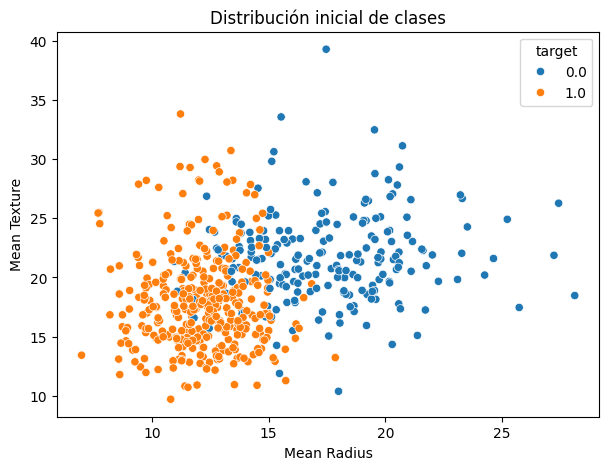

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df_cancer,
    x="mean radius",
    y="mean texture",
    hue="target"
)

plt.title("Distribución inicial de clases")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.show()

## Step 6 - Division de entrenamiento y prueba

# División Train/Test

Se divide el dataset en:
- 75% entrenamiento
- 25% prueba

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(426, 2)
(143, 2)


## Paso 6 - Escalamiento de Datos

### Escalamiento MinMax

Los datos se escalan entre 0 y 1
para mejorar el entrenamiento de la red neuronal.### Creación de variables de entrada y salida

X_train contiene las variables independientes.

y_train contiene las etiquetas o clases.

In [12]:
# Escalador
scaler = MinMaxScaler()

# Ajuste y transformación entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformación prueba
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (426, 2)
X_test: (143, 2)
y_train: (426,)
y_test: (143,)


### Paso 7 - Visualizacion de datos escalados

### Datos Escalados

Se visualizan los datos ya normalizados.### Construcción de la red neuronal

Se utiliza una sola neurona ya que:

- El problema es de clasificación binaria
- Esto equivale matemáticamente a una regresión logística

Características del modelo:

- 2 entradas
- 1 salida
- Función de activación Sigmoid
- Optimizador Adam
- Función de pérdida Binary Crossentropy

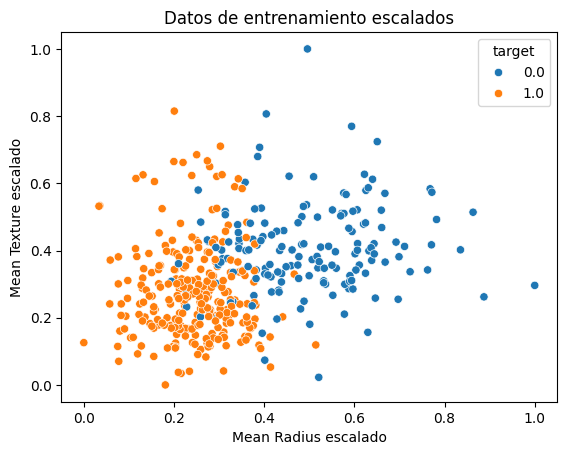

In [13]:
sns.scatterplot(
    x=X_train_scaled[:,0],
    y=X_train_scaled[:,1],
    hue=y_train
)

plt.title("Datos de entrenamiento escalados")
plt.xlabel("Mean Radius escalado")
plt.ylabel("Mean Texture escalado")
plt.show()

## Paso 8 - Modelo 1 perceptron simple

### Modelo 1: Perceptrón Simple

Se crea una red neuronal con:
- 2 entradas
- 1 neurona de salida
- Activación Sigmoid

Este modelo representa un perceptrón simple.### Entrenamiento del modelo

Parámetros utilizados:

- epochs = 100
- batch_size = 50
- shuffle = True

El modelo aprenderá los pesos óptimos
para clasificar correctamente los datos.

In [17]:
tf.random.set_seed(42)
model = Sequential()

model.add(
    Dense(
        units=1,
        input_dim=2,
        activation='sigmoid'
    )
)

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Paso 10 - Entrenamienro del modelo

### Entrenamiento

Se entrena el modelo durante 100 épocas.### Resumen de la arquitectura

Se muestran:

- Número de capas
- Número de parámetros
- Dimensiones de entrada y salida

In [18]:
hist = model.fit(
    x=X_train_scaled,
    y=y_train,
    verbose=1,
    batch_size=50,
    epochs=100,
    shuffle=True
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - loss: 0.7898  
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - loss: 0.7753 
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - loss: 0.7643 
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6221 - loss: 0.7560 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6221 - loss: 0.7493 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6221 - loss: 0.7432 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6244 - loss: 0.7372 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6244 - loss: 0.7312 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - loss: 0.7250 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - loss: 0.7189 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - loss: 0.7127 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6268 - lo

## Paso 11 - resumen del modelo

### Arquitectura del Modelo

In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8 (36.00 B)

## Paso 12 - Graficar exactitud

### Evolución de la exactitud

Se observa cómo mejora el accuracy
durante el entrenamiento.

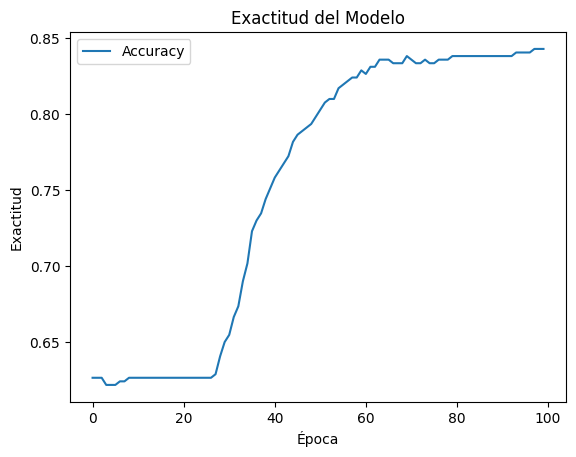

In [20]:
# ------------------------------------------------------------
# Graficar accuracy
# ------------------------------------------------------------

plt.plot(hist.history['accuracy'])

plt.title("Exactitud del Modelo")
plt.ylabel("Exactitud")
plt.xlabel("Época")

plt.legend(['Accuracy'])

plt.show()

## Paso 13 - Graficar error

### Evolución del error

Se visualiza cómo disminuye la función de pérdida.

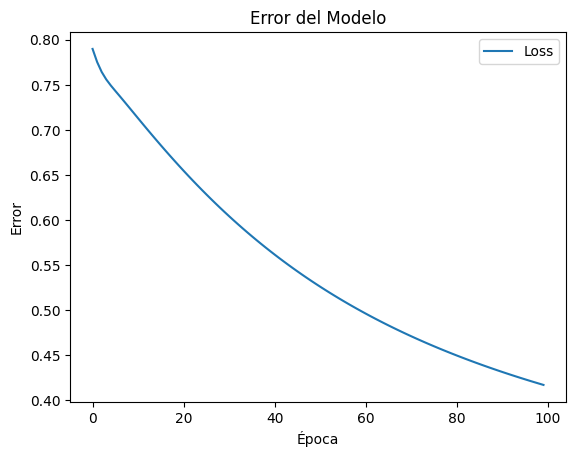

In [21]:
# ------------------------------------------------------------
# Graficar pérdida (loss)
# ------------------------------------------------------------

plt.plot(hist.history['loss'])

plt.title("Error del Modelo")
plt.ylabel("Error")
plt.xlabel("Época")

plt.legend(['Loss'])

plt.show()

## Paso 14 - Visualizar frontera de decision

### Visualización de resultados

### Frontera de Clasificación

Se visualiza la frontera de decisión aprendida
por la red neuronal.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step


C:\Users\baraj\AppData\Local\Temp\ipykernel_64240\1535418120.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


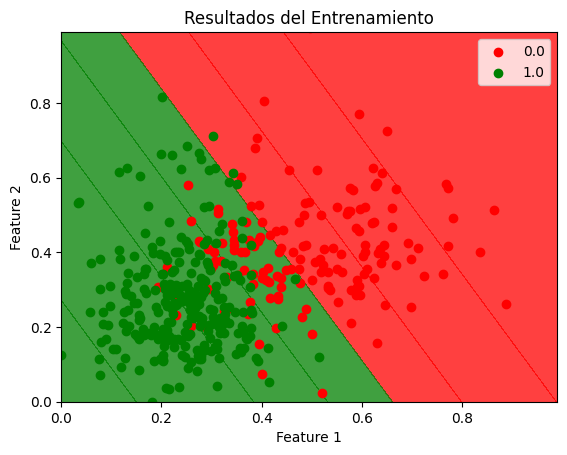

In [22]:
X_grid, y_grid = X_train_scaled, y_train

X1, X2 = np.meshgrid(
    np.arange(
        start=X_grid[:,0].min(),
        stop=X_grid[:,0].max(),
        step=0.01
    ),

    np.arange(
        start=X_grid[:,1].min(),
        stop=X_grid[:,1].max(),
        step=0.01
    )
)

predictions = model.predict(
    np.array([X1.ravel(), X2.ravel()]).T
)

predictions = predictions.reshape(X1.shape)

plt.contourf(
    X1,
    X2,
    predictions,
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_grid)):

    plt.scatter(
        X_grid[y_grid == j, 0],
        X_grid[y_grid == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Resultados del Entrenamiento')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend()

plt.show()

## Paso 15 - Mostrar pesos del modelo

### Pesos aprendidos por la neurona

La red neuronal aprende:

- Pesos (weights)
- Biases

In [23]:
# ------------------------------------------------------------
# Obtener pesos y bias
# ------------------------------------------------------------

weights, biases = model.layers[0].get_weights()

# ------------------------------------------------------------
# Mostrar pesos
# ------------------------------------------------------------

print("Pesos aprendidos:")
print(weights)

# ------------------------------------------------------------
# Mostrar bias
# ------------------------------------------------------------

print("\nBias aprendido:")
print(biases)

Pesos aprendidos:
[[-4.6894813]
 [-2.5792217]]

Bias aprendido:
[2.898234]


## Paso 16 - Predicciones

### Prueba con un dato arbitrario

Se evalúa una nueva entrada:

- Distancia = 0.1
- Altura = 0.2

El modelo devuelve una probabilidad.

In [24]:
y_predict = (
    model.predict(X_test_scaled) > 0.5
).astype("int32")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


## Paso 17 - Matriz de confusion

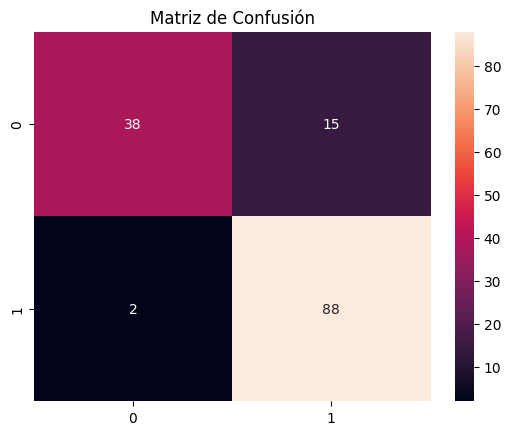

In [25]:
cm = confusion_matrix(y_test, y_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión")

plt.show()

## Paso 18 - Reporte de clasificacion

In [26]:
print(
    classification_report(
        y_test,
        y_predict
    )
)

              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82        53
         1.0       0.85      0.98      0.91        90

    accuracy                           0.88       143
   macro avg       0.90      0.85      0.86       143
weighted avg       0.89      0.88      0.88       143



## Paso 19 - Modelo Mejorado - Red Neuronal Profunda

In [27]:
model = Sequential()

# Primera capa oculta
model.add(
    Dense(
        units=20,
        input_dim=2,
        activation='relu'
    )
)

# Segunda capa oculta
model.add(
    Dense(
        units=20,
        activation='relu'
    )
)

# Tercera capa oculta
model.add(
    Dense(
        units=20,
        activation='relu'
    )
)

# Capa de salida
model.add(
    Dense(
        units=1,
        activation='sigmoid'
    )
)

# Compilación
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Paso 20 - Entrenamiento del modelo profundo

In [28]:
hist = model.fit(
    x=X_train_scaled,
    y=y_train,
    verbose=1,
    batch_size=50,
    epochs=100,
    shuffle=True
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5657 - loss: 0.6757  
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7230 - loss: 0.5886 
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8521 - loss: 0.4393 
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8521 - loss: 0.3245 
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.2965 
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8685 - loss: 0.2946 
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8685 - loss: 0.2965 
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8756 - loss: 0.2868 
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8967 - loss: 0.2614 
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8850 - loss: 0.2593 
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8897 - loss: 0.2621 
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8897 - lo

## Paso 21 - Perdida del modelo profundo

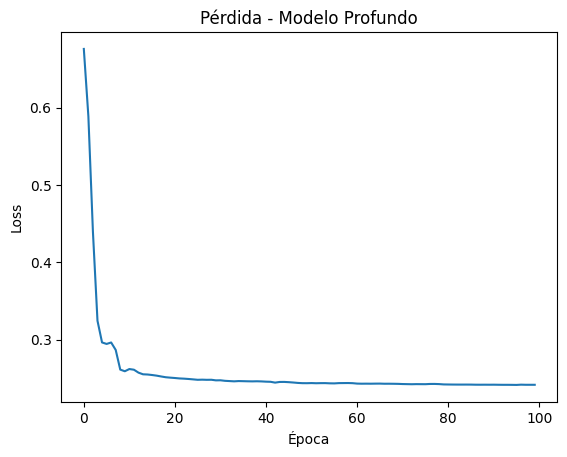

In [29]:
plt.plot(hist.history['loss'])

plt.title("Pérdida - Modelo Profundo")
plt.xlabel("Época")
plt.ylabel("Loss")

plt.show()

## Paso 22 - Frontera de decision mejorada

### Frontera de Decisión Mejorada

Ahora la red neuronal puede aprender
la forma curva del dataset.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step


C:\Users\baraj\AppData\Local\Temp\ipykernel_64240\1983597610.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


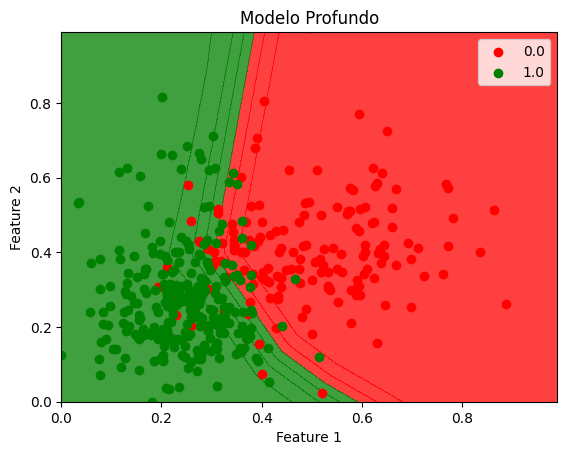

In [30]:
X_grid, y_grid = X_train_scaled, y_train

X1, X2 = np.meshgrid(
    np.arange(
        start=X_grid[:,0].min(),
        stop=X_grid[:,0].max(),
        step=0.01
    ),

    np.arange(
        start=X_grid[:,1].min(),
        stop=X_grid[:,1].max(),
        step=0.01
    )
)

predictions = model.predict(
    np.array([X1.ravel(), X2.ravel()]).T
)

predictions = predictions.reshape(X1.shape)

plt.contourf(
    X1,
    X2,
    predictions,
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_grid)):

    plt.scatter(
        X_grid[y_grid == j, 0],
        X_grid[y_grid == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Modelo Profundo')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.legend()

plt.show()

## Paso 23 - Evaluacion Final 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


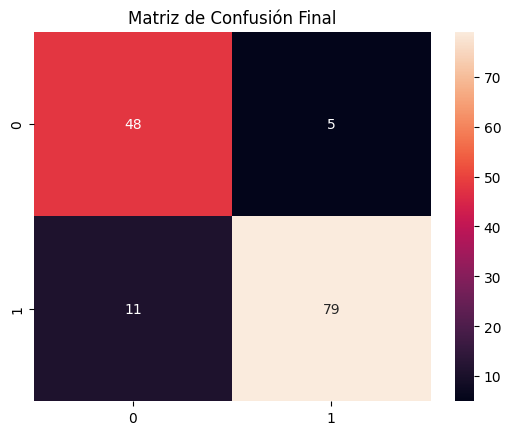

In [31]:
y_predict = (
    model.predict(X_test_scaled) > 0.5
).astype("int32")

cm = confusion_matrix(y_test, y_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusión Final")

plt.show()

## Paso 24 - Reporte final

# Conclusiones

- El perceptrón simple solamente puede aprender
  fronteras lineales.

- El dataset make_moons requiere una frontera
  no lineal para separar correctamente las clases.

- Las capas ocultas y las funciones de activación ReLU
  permiten aprender patrones complejos.

- La red neuronal profunda obtiene mejor exactitud
  y una mejor frontera de clasificación.

- Keras facilita enormemente la construcción
  y entrenamiento de redes neuronales.

### 24. Conclusiones del modelo profundo

Se implementó una red neuronal profunda utilizando:

- 3 capas ocultas
- 20 neuronas por capa
- Función de activación ReLU
- Función Sigmoid en la salida
- Optimizador Adam

### Resultados observados

Comparado con el modelo inicial de una sola neurona, el modelo profundo logró:

- Mejor separación no lineal entre clases
- Mayor capacidad de aprendizaje
- Menor error durante el entrenamiento
- Frontera de decisión más compleja y precisa

La gráfica de entrenamiento mostró:

- Incremento progresivo de accuracy
- Disminución constante de la función de pérdida
- Convergencia estable del modelo

### Interpretación de la frontera de decisión

La frontera de decisión ya no es lineal.

Ahora el modelo puede adaptarse mejor a regiones complejas del espacio de características, lo cual permite clasificar mejor datos que no son separables mediante una línea recta.

Esto es una ventaja importante de las redes neuronales profundas sobre modelos lineales simples.

### Limitaciones del modelo

Aunque el desempeño mejoró, todavía existen algunas limitaciones:

- Solo se utilizaron 2 variables del dataset
- No se agregó validación durante el entrenamiento
- No se implementó regularización
- El modelo podría sobreajustarse con más épocas

### Posibles mejoras futuras

Para mejorar aún más el desempeño del modelo se podría:

- Utilizar las 30 variables originales del dataset
- Implementar Dropout
- Agregar Batch Normalization
- Utilizar Early Stopping
- Ajustar hiperparámetros
- Probar diferentes learning rates
- Incrementar o disminuir neuronas y capas
- Agregar conjunto de validación

### Conclusión general

Las redes neuronales profundas permiten resolver problemas de clasificación binaria con fronteras de decisión complejas.

Incluso utilizando únicamente dos variables, el modelo fue capaz de aprender patrones no lineales y mejorar considerablemente respecto al modelo simple de una sola neurona.